# Tasa de conversión por contexto tecnológico y de tráfico

**Autor:** John Janer Buila Ferrin

La pregunta de negocio del proyecto pregunta explícitamente cómo cambia la
tasa de compra según, entre otras cosas, "la fuente de tráfico y otras
características de contexto". El EDA inicial (`01_eda.ipynb`) visualiza mes,
tipo de visitante y fin de semana, pero no `OperatingSystems`, `Browser`,
`Region` ni `TrafficType`. Este notebook cierra ese vacío.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from online_shoppers.data import load_dataset

ROOT = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
DATA_PATH = ROOT / 'data/raw/online_shoppers_intention.csv'
FIGURES_PATH = ROOT / 'reports/figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

sessions = load_dataset(DATA_PATH)
context_columns = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']
sessions[context_columns].nunique()

OperatingSystems     8
Browser             13
Region               9
TrafficType         20
dtype: int64

## 1. Conversión por categoría, filtrando categorías con muy pocas sesiones

Con categorías de menos de 50 sesiones, la tasa de conversión es poco
confiable (mucho ruido estadístico), así que se excluyen de la comparación
visual, aunque se mantienen en el dataset completo para el modelamiento.

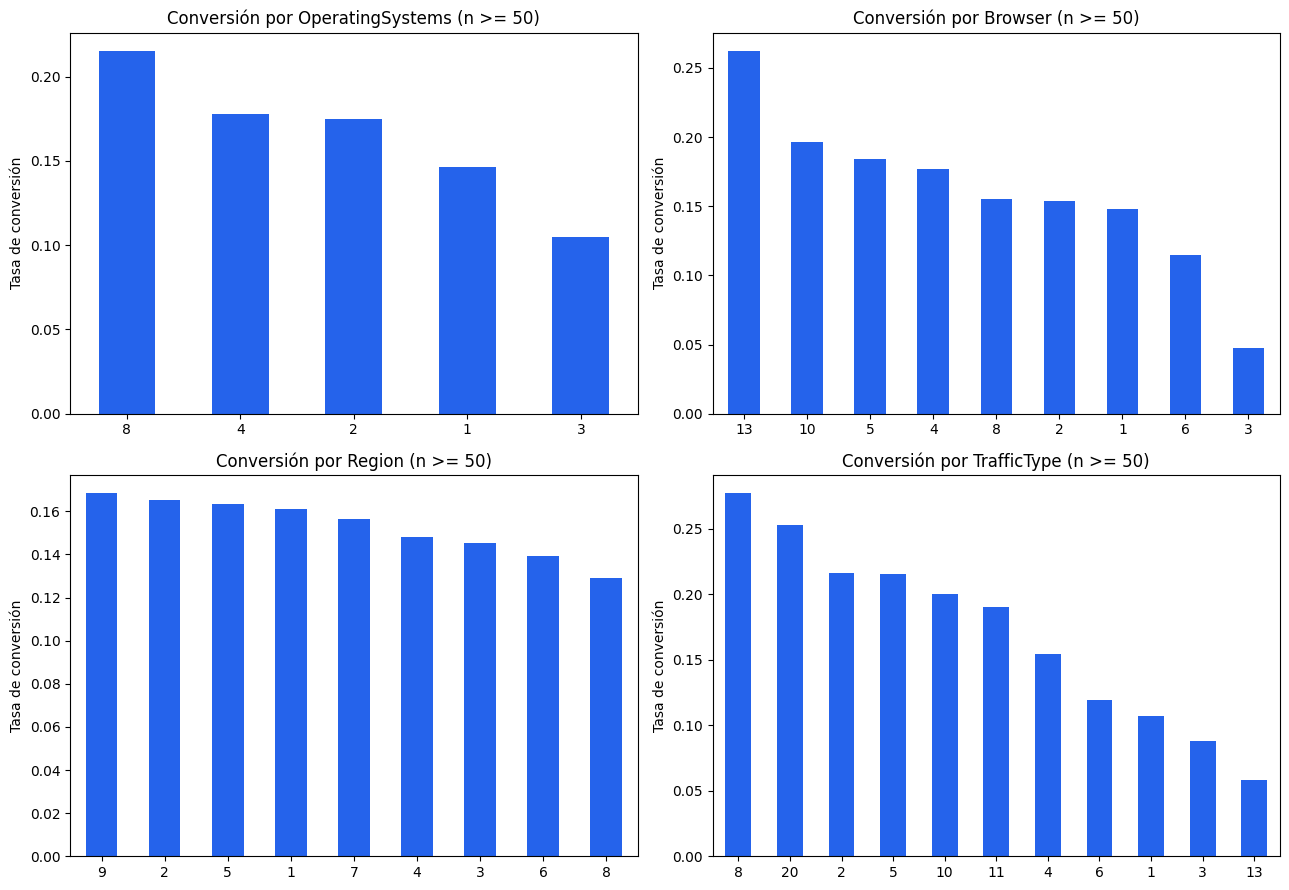

In [2]:
MIN_SESSIONS = 50

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for axis, column in zip(axes.flat, context_columns):
    grouped = sessions.groupby(column, observed=True)['Revenue'].agg(['mean', 'count'])
    grouped = grouped[grouped['count'] >= MIN_SESSIONS].sort_values('mean', ascending=False)
    grouped['mean'].plot.bar(ax=axis, color='#2563eb')
    axis.set(title=f'Conversión por {column} (n >= {MIN_SESSIONS})', xlabel='', ylabel='Tasa de conversión')
    axis.tick_params(axis='x', rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'conversion_by_tech_traffic_context.png', dpi=150)
plt.show()

## 2. Rango de variación por variable (máximo - mínimo, entre categorías con n >= 50)

In [3]:
spread = {}
for column in context_columns:
    grouped = sessions.groupby(column, observed=True)['Revenue'].agg(['mean', 'count'])
    grouped = grouped[grouped['count'] >= MIN_SESSIONS]
    spread[column] = {
        'min': grouped['mean'].min(),
        'max': grouped['mean'].max(),
        'rango': grouped['mean'].max() - grouped['mean'].min(),
    }
import pandas as pd
pd.DataFrame(spread).T.round(3).sort_values('rango', ascending=False)

,min,max,rango
TrafficType,0.058,0.277,0.219
Browser,0.048,0.262,0.215
OperatingSystems,0.105,0.215,0.110
Region,0.129,0.168,0.039


## 3. Conclusión

- `TrafficType` es la variable de contexto con mayor variación: entre 5,8&nbsp;%
  y 27,7&nbsp;% de conversión según la fuente (rango ~22 puntos porcentuales),
  aun excluyendo categorías con pocas sesiones. Es la más informativa de este
  grupo para diferenciar sesiones.
- `OperatingSystems`, `Browser` y `Region` muestran variación bastante menor
  y menos consistente, probablemente porque reflejan más el dispositivo del
  usuario que su intención de compra.
- **Recomendación:** priorizar `TrafficType` como variable de contexto en el
  modelamiento y en el tablero (por ejemplo como filtro), y tratar
  `OperatingSystems`/`Browser`/`Region` como variables de control más que
  como señales fuertes por sí solas.